# Age and Gender Prediction using ResNet50 (Transfer Learning)

This notebook trains a **ResNet50**-based deep learning model on the **UTKFace** dataset to simultaneously predict:
- **Age** — as a regression task (normalized to [0, 1])
- **Gender** — as a binary classification task

The approach uses **transfer learning** from ImageNet weights, followed by a two-phase training strategy:
1. **Phase 1** — Train only the custom head (base frozen)
2. **Phase 2** — Fine-tune the last 30 layers of ResNet50

A third pass addresses overfitting using data augmentation and a revised model head.


## Environment Setup

The UTKFace dataset is downloaded directly from Kaggle using the `kagglehub` library.
Standard libraries for numerical computation, data handling, and visualization are then imported.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhikjha/utk-face-cropped")

print("Path to dataset files:", path)

100%|██████████| 232M/232M [00:13<00:00, 17.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abhikjha/utk-face-cropped/versions/1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
folder_path = 'utkcropped'

## Dataset Loading

The UTKFace dataset encodes labels directly in image filenames using the pattern `age_gender_race_date.jpg`.

This section:
- Lists all images in the dataset folder
- Visualizes a sample grid with age labels
- Parses age and gender from filenames into a structured DataFrame
- Filters out any rows with invalid gender labels (e.g., `gender != 3`)


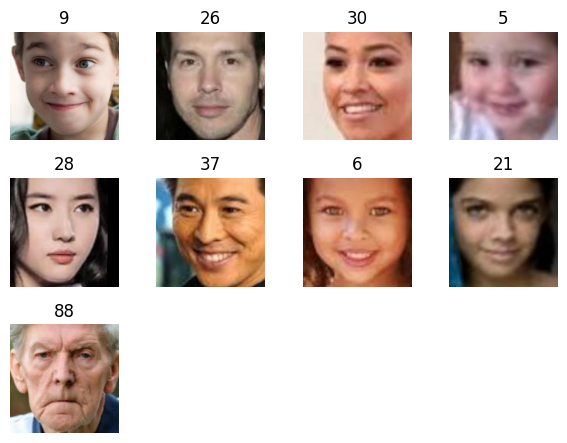

In [6]:
from PIL import Image

images = os.listdir(folder_path)

plt.figure(figsize=(6,6))

for i, img_name in enumerate(images[:9]):
    img_path = os.path.join(folder_path, img_name)
    img = Image.open(img_path)

    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(img_name.split('_')[0])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
    try:
        age.append(int(file.split('_')[0]))
        gender.append(int(file.split('_')[1]))
        img_path.append(file)
    except:
        print("Skipped:", file)

Skipped: utkcropped


In [8]:
print(len(age), len(gender), len(img_path))

23709 23709 23709


In [9]:
df = pd.DataFrame({'age': age, 'gender': gender, 'img_path': img_path})

In [10]:
df.head()

,age,gender,img_path
0,9,0,9_0_0_20170110225018913.jpg.chip.jpg
1,26,0,26_0_0_20170117172931573.jpg.chip.jpg
2,30,1,30_1_4_20170117202935574.jpg.chip.jpg
3,5,1,5_1_4_20161221201952681.jpg.chip.jpg
4,28,1,28_1_2_20170116164602956.jpg.chip.jpg


In [11]:
df = df[df['gender']!=3]

In [12]:
df.shape

(23708, 3)

## Age Normalization

Raw age values range from 0 to 116 in the UTKFace dataset.
Normalizing to **[0, 1]** by dividing by 116 stabilizes regression training and makes the sigmoid output in the age branch meaningful.

Both age and gender columns are also converted to strings, as required by `flow_from_dataframe` when using `class_mode='multi_output'`.


In [13]:
df['age'] = df['age'] / 116.0

# Convert to string so flow_from_dataframe can handle multi-output
df['age'] = df['age'].astype(str)
df['gender'] = df['gender'].astype(str)

In [14]:
df.head()

,age,gender,img_path
0,0.07758620689655173,0,9_0_0_20170110225018913.jpg.chip.jpg
1,0.22413793103448276,0,26_0_0_20170117172931573.jpg.chip.jpg
2,0.25862068965517243,1,30_1_4_20170117202935574.jpg.chip.jpg
3,0.04310344827586207,1,5_1_4_20161221201952681.jpg.chip.jpg
4,0.2413793103448276,1,28_1_2_20170116164602956.jpg.chip.jpg


## Train-Validation-Test Split

The dataset is divided into three subsets:
- **64%** — Training data
- **16%** — Validation data (20% of the training portion)
- **20%** — Test data (held out for final evaluation)

A fixed random seed ensures the splits are reproducible across runs.


In [15]:
from sklearn.model_selection import train_test_split

# 80% train+val, 20% test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

# Split train into train + validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,   # 20% of train -> validation
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(15172, 3)
(3794, 3)
(4742, 3)


## Data Generators

`ImageDataGenerator` is used to load images in batches directly from disk, avoiding the need to load the entire UTKFace dataset into memory.

ResNet50's built-in `preprocess_input` is applied here (instead of simple rescaling), which performs mean subtraction and channel normalization as expected by the ImageNet-pretrained weights.

Three generators are created: training, validation, and test — all at **224×224** resolution to match ResNet50's expected input.


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

Found 15172 validated image filenames.
Found 3794 validated image filenames.
Found 4742 validated image filenames.


## Generator Wrapper

`flow_from_dataframe` with `class_mode='multi_output'` returns labels as a **list** `[age_labels, gender_labels]`.

However, the multi-output Keras model expects labels as a **dict** keyed by output layer names (`age_out`, `gender_out`).

This wrapper converts the list format to a dict format on-the-fly during training, bridging the two interfaces cleanly.


In [ ]:
def multi_output_wrapper(generator):
    for x, y in generator:
        age_labels = y[0].astype('float32')
        gender_labels = y[1].astype('float32')
        yield x, {'age_out': age_labels, 'gender_out': gender_labels}

train_gen = multi_output_wrapper(train_generator)
val_gen = multi_output_wrapper(val_generator)
test_gen = multi_output_wrapper(test_generator)

# ResNet50 Transfer Learning Model

A pretrained **ResNet50** (ImageNet weights, no top) is used as the feature extraction backbone.

Two separate output branches are attached on top of a shared `GlobalAveragePooling2D` layer:
- **Age branch** — Three Dense layers (512 → 256 → 128) with BatchNormalization, ending with a sigmoid output for normalized age
- **Gender branch** — One Dense layer (128) with BatchNormalization and Dropout, ending with a sigmoid for binary classification

**Training strategy:**
- Phase 1: Base frozen — only the custom head is trained at a higher learning rate (1e-3)
- Phase 2: Last 30 base layers unfrozen — fine-tuned at a lower learning rate (1e-4)


In [18]:
from tensorflow import keras
from keras.applications import ResNet50
from keras.layers import *
from keras.models import Model

In [19]:
conv_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# Freeze all base layers first
conv_base.trainable = False

In [ ]:
x = conv_base.output
x = GlobalAveragePooling2D()(x)

# Age branch
age_output = Dense(512, activation='relu')(x)
age_output = BatchNormalization()(age_output)

age_output = Dense(256, activation='relu')(age_output)
age_output = BatchNormalization()(age_output)

age_output = Dense(128, activation='relu')(age_output)
age_output = BatchNormalization()(age_output)

age_output = Dense(1, activation='sigmoid', name='age_out')(age_output)  # sigmoid since age is normalized 0-1

# Gender branch
gender_output = Dense(128, activation='relu')(x)
gender_output = BatchNormalization()(gender_output)
gender_output = Dropout(0.5)(gender_output)
gender_output = Dense(1, activation='sigmoid', name='gender_out')(gender_output)

In [ ]:
model = Model(
    inputs=conv_base.input,
    outputs=[age_output, gender_output]
)

In [ ]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,067,650 (95.63 MB)

 Trainable params: 15,928,066 (60.76 MB)

 Non-trainable params: 9,139,584 (34.86 MB)

## Phase 1: Head-Only Training

The ResNet50 base is **completely frozen** in this phase — only the newly added dense layers are trainable.

This warm-up step prevents the pretrained weights from being disrupted by large random gradients from the untrained head.

Training runs for up to **10 epochs** with:
- `Adam` optimizer at learning rate `1e-3`
- `Huber` loss for age regression (robust to outliers)
- `Binary Crossentropy` for gender classification
- Early stopping (patience = 3) and model checkpointing

A quick evaluation on the test set is done at the end of Phase 1 to benchmark baseline performance.


In [29]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        'age_out': Huber(),
        'gender_out': 'binary_crossentropy'
    },
    metrics={
        'age_out': ['mae'],
        'gender_out': ['accuracy']
    }
)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_phase1 = ModelCheckpoint(
    'ResNet50_phase1.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=val_gen,
    validation_steps=len(val_generator),
    epochs=10,
    callbacks=[early_stopping, checkpoint_phase1]
)

Epoch 1/10


KeyboardInterrupt: 

## Phase 1 Evaluation

After Phase 1 head training, a quick evaluation is run on the test set to establish a **baseline** before fine-tuning.
This helps measure how much fine-tuning improves performance in Phase 2.


In [ ]:
eval_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

age_pred, gender_pred = model.predict(eval_generator)

Found 4742 validated image filenames.
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step


In [ ]:
from sklearn.metrics import accuracy_score

y_test_gender = test_df['gender'].astype(float).values

gender_pred_binary = (gender_pred > 0.5).astype(int)

gender_acc = accuracy_score(
    y_test_gender,
    gender_pred_binary.flatten()
)

print("Gender Accuracy:", gender_acc)

Gender Accuracy: 0.8897089835512442


In [ ]:
from sklearn.metrics import mean_absolute_error

y_test_age = test_df['age'].astype(float).values

# Denormalize age predictions back to actual years
age_pred_years = age_pred.flatten() * 116.0
y_test_age_years = y_test_age * 116.0

mae = mean_absolute_error(y_test_age_years, age_pred_years)

print("Age MAE (years):", mae)

Age MAE (years): 7.109361144817363


## Phase 2: Fine-Tuning

The **last 30 layers** of ResNet50 are unfrozen and allowed to update during this phase.
All earlier layers remain frozen to preserve low-level ImageNet features.

A much lower learning rate (`1e-4`) is used to make small, careful updates to the pretrained weights without catastrophic forgetting.

Additional callbacks:
- `ReduceLROnPlateau` — halves the learning rate if validation loss plateaus for 2 epochs
- Early stopping (patience = 5)
- Generators are re-wrapped since they were exhausted in Phase 1

Training runs for up to **30 epochs**.


In [ ]:
conv_base.trainable = True

for layer in conv_base.layers[:-30]:
    layer.trainable = False

for layer in conv_base.layers[-30:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # lower lr for fine-tuning
    loss={
        'age_out': Huber(),
        'gender_out': 'binary_crossentropy'
    },
    metrics={
        'age_out': ['mae'],
        'gender_out': ['accuracy']
    }
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint_phase2 = ModelCheckpoint(
    'ResNet50_final.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Re-wrap generators since they were exhausted in phase 1
train_gen = multi_output_wrapper(train_generator)
val_gen = multi_output_wrapper(val_generator)
test_gen = multi_output_wrapper(test_generator)

In [ ]:
history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=val_gen,
    validation_steps=len(val_generator),
    epochs=30,
    callbacks=[early_stopping_2, checkpoint_phase2, reduce_lr]
)

Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - age_out_loss: 0.0342 - age_out_mae: 0.2040 - gender_out_accuracy: 0.8779 - gender_out_loss: 0.2866 - loss: 0.3208
Epoch 1: val_loss improved from None to 0.27326, saving model to ResNet50_final.keras

Epoch 1: finished saving model to ResNet50_final.keras
475/475 ━━━━━━━━━━━━━━━━━━━━ 113s 189ms/step - age_out_loss: 0.0240 - age_out_mae: 0.1670 - gender_out_accuracy: 0.9030 - gender_out_loss: 0.2450 - loss: 0.2690 - val_age_out_loss: 0.0109 - val_age_out_mae: 0.1138 - val_gender_out_accuracy: 0.9104 - val_gender_out_loss: 0.2624 - val_loss: 0.2733 - learning_rate: 1.0000e-04
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - age_out_loss: 0.0110 - age_out_mae: 0.1146 - gender_out_accuracy: 0.9431 - gender_out_loss: 0.1456 - loss: 0.1566
Epoch 2: val_loss improved from 0.27326 to 0.24835, saving model to ResNet50_final.keras

Epoch 2: finished saving model to ResNet50_final.keras
475/475 ━━━━━━━━━━━━━━━━━━━━ 77s 163ms/step - ag

## Phase 2 Training Results

The following plots visualize model performance across fine-tuning epochs:
- **Gender Classification Accuracy** — training vs. validation
- **Age Prediction MAE** — training vs. validation (in normalized units)
- **Total Loss** — combined weighted loss across both outputs

Divergence between training and validation curves may indicate overfitting — addressed in the next section.


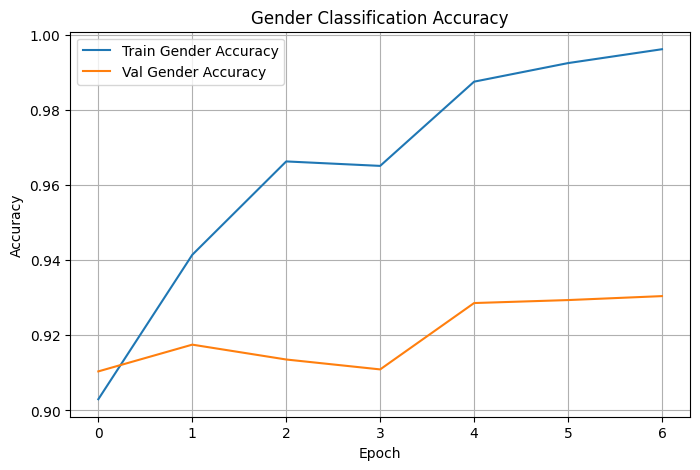

In [ ]:
# Gender Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_phase2.history['gender_out_accuracy'], label='Train Gender Accuracy')
plt.plot(history_phase2.history['val_gender_out_accuracy'], label='Val Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()

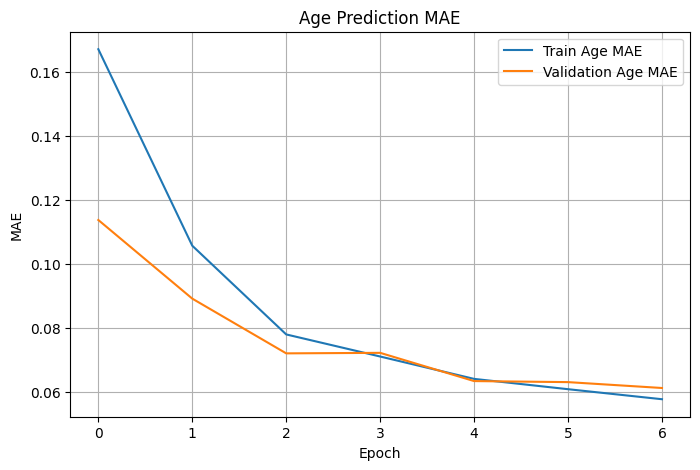

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_phase2.history['age_out_mae'],
         label='Train Age MAE')

plt.plot(history_phase2.history['val_age_out_mae'],
         label='Validation Age MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age Prediction MAE')
plt.legend()
plt.grid(True)

plt.show()

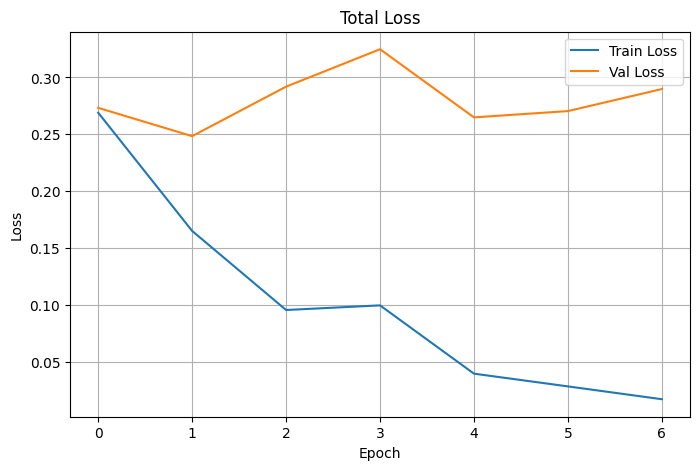

In [ ]:
# Total Loss
plt.figure(figsize=(8, 5))
plt.plot(history_phase2.history['loss'], label='Train Loss')
plt.plot(history_phase2.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)
plt.show()

## Final Model Evaluation (Phase 2)

The best checkpoint saved during Phase 2 (`ResNet50_final.keras`) is reloaded for evaluation.

A fresh generator with `shuffle=False` is used so that predictions remain aligned with the test DataFrame row order.

Metrics reported:
- **Gender Accuracy** — fraction of correctly predicted genders
- **Age MAE (years)** — mean absolute error after denormalizing predictions back to the 0–116 year scale


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('ResNet50_final.keras')

In [ ]:
# Fresh generator with no shuffle for evaluation
eval_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

age_pred, gender_pred = model.predict(eval_generator)

Found 4742 validated image filenames.
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step


In [ ]:
from sklearn.metrics import accuracy_score

y_test_gender = test_df['gender'].astype(float).values

gender_pred_binary = (gender_pred > 0.5).astype(int)

gender_acc = accuracy_score(
    y_test_gender,
    gender_pred_binary.flatten()
)

print("Gender Accuracy:", gender_acc)

Gender Accuracy: 0.9175453395191903


In [ ]:
from sklearn.metrics import mean_absolute_error

y_test_age = test_df['age'].astype(float).values

# Denormalize age predictions back to actual years
age_pred_years = age_pred.flatten() * 116.0
y_test_age_years = y_test_age * 116.0

mae = mean_absolute_error(y_test_age_years, age_pred_years)

print("Age MAE (years):", mae)

Age MAE (years): 10.23966035713178


## Overfitting Solution: Data Augmentation + Revised Head

If the Phase 2 model shows signs of overfitting (train loss << val loss), this section applies two remedies:

**1. Data Augmentation** — The training generator now applies random transformations:
- Rotation (±15°), width/height shifts (10%), zoom (10%), horizontal flip
- Validation and test generators remain unaugmented

**2. Simplified Model Head** — The age branch is simplified (Dense 256 → linear output with Dropout 0.3), reducing overfitting capacity.

**3. Loss Weighting** — Age loss weight is set to 1.0 and gender loss to 0.3, reflecting the relative difficulty of each task.

This combined approach (Phase 3) is trained for up to **30 epochs** with the same fine-tuning setup.


In [16]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [17]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

Found 15172 validated image filenames.
Found 3794 validated image filenames.
Found 4742 validated image filenames.


In [20]:
def multi_output_wrapper(generator):
    for x, y in generator:
        age_labels = y[0].astype('float32')
        gender_labels = y[1].astype('float32')
        yield x, {'age_out': age_labels, 'gender_out': gender_labels}

train_gen = multi_output_wrapper(train_generator)
val_gen = multi_output_wrapper(val_generator)
test_gen = multi_output_wrapper(test_generator)

In [25]:
conv_base.trainable = True

for layer in conv_base.layers[:-30]:
    layer.trainable = False

for layer in conv_base.layers[-30:]:
    layer.trainable = True

In [26]:
x = conv_base.output
x = GlobalAveragePooling2D()(x)

# Age branch
age_output = Dense(256, activation='relu')(x)
age_output = Dropout(0.3)(age_output)
age_output = Dense(1, activation='linear', name='age_out')(age_output)  # sigmoid since age is normalized 0-1

# Gender branch
gender_output = Dense(128, activation='relu')(x)
gender_output = BatchNormalization()(gender_output)
gender_output = Dropout(0.5)(gender_output)
gender_output = Dense(1, activation='sigmoid', name='gender_out')(gender_output)

In [27]:
model = Model(
    inputs=conv_base.input,
    outputs=[age_output, gender_output]
)

In [33]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # lower lr for fine-tuning
    loss={
        'age_out': Huber(),
        'gender_out': 'binary_crossentropy'
    },

    loss_weights={'age_out': 1.0, 'gender_out': 0.3},

    metrics={
        'age_out': ['mae'],
        'gender_out': ['accuracy']
    }
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint_phase2 = ModelCheckpoint(
    'ResNet50_Data_Aug.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [34]:
history_phase3 = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=val_gen,
    validation_steps=len(val_generator),
    epochs=30,
    callbacks=[early_stopping_2, checkpoint_phase2, reduce_lr]
)

Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - age_out_loss: 0.0728 - age_out_mae: 0.2631 - gender_out_accuracy: 0.7853 - gender_out_loss: 0.4969 - loss: 0.2219
Epoch 1: val_loss improved from None to 0.09274, saving model to ResNet50_Data_Aug.keras

Epoch 1: finished saving model to ResNet50_Data_Aug.keras
475/475 ━━━━━━━━━━━━━━━━━━━━ 263s 501ms/step - age_out_loss: 0.0296 - age_out_mae: 0.1620 - gender_out_accuracy: 0.8343 - gender_out_loss: 0.3985 - loss: 0.1494 - val_age_out_loss: 0.0068 - val_age_out_mae: 0.0882 - val_gender_out_accuracy: 0.8811 - val_gender_out_loss: 0.2868 - val_loss: 0.0927 - learning_rate: 1.0000e-04
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - age_out_loss: 0.0070 - age_out_mae: 0.0903 - gender_out_accuracy: 0.8822 - gender_out_loss: 0.2737 - loss: 0.0891
Epoch 2: val_loss did not improve from 0.09274
475/475 ━━━━━━━━━━━━━━━━━━━━ 214s 452ms/step - age_out_loss: 0.0066 - age_out_mae: 0.0875 - gender_out_accuracy: 0.8858 - gender_out_loss: 0

## Phase 3 Training Results

The plots below show model performance for the augmented, regularized model (Phase 3).
Compare these curves against Phase 2 to see the effect of augmentation and the simplified head on overfitting.


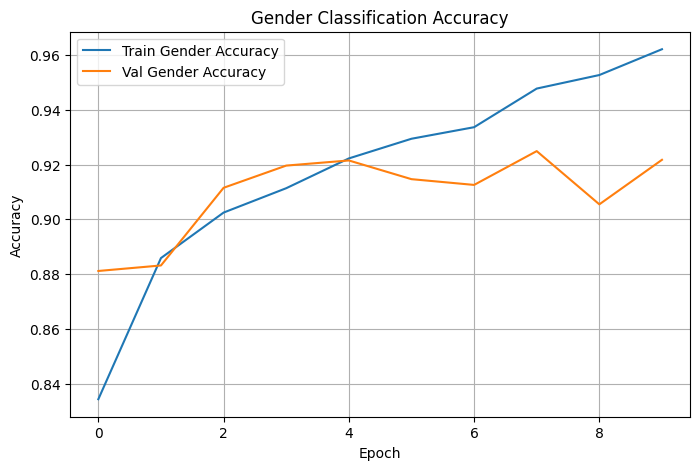

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_phase3.history['gender_out_accuracy'], label='Train Gender Accuracy')
plt.plot(history_phase3.history['val_gender_out_accuracy'], label='Val Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()

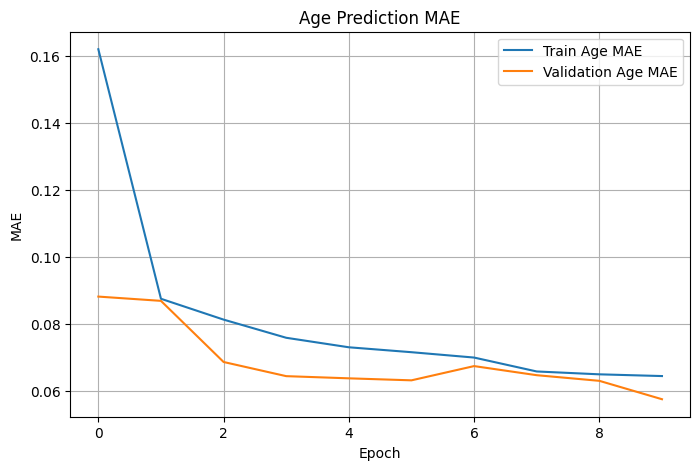

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history_phase3.history['age_out_mae'],
         label='Train Age MAE')

plt.plot(history_phase3.history['val_age_out_mae'],
         label='Validation Age MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age Prediction MAE')
plt.legend()
plt.grid(True)

plt.show()

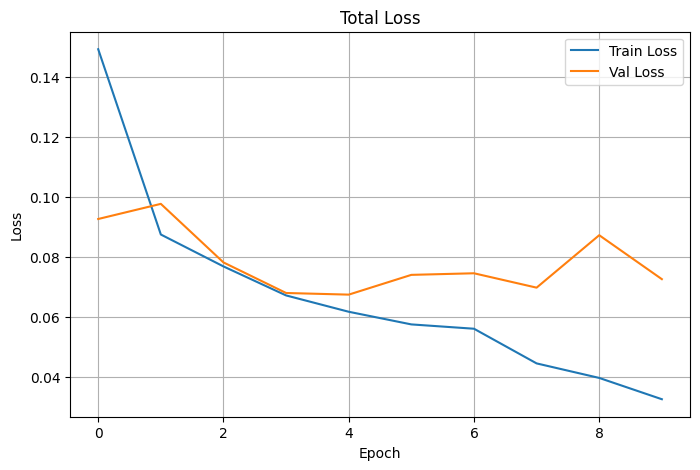

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_phase3.history['loss'], label='Train Loss')
plt.plot(history_phase3.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)
plt.show()

## Final Model Evaluation (Phase 3 — Augmented)

The best checkpoint from Phase 3 (`ResNet50_Data_Aug.keras`) is evaluated on the test set.
Results here reflect the final, most regularized version of the model.


In [39]:
# Fresh generator with no shuffle for evaluation
eval_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

age_pred, gender_pred = model.predict(eval_generator)

Found 4742 validated image filenames.
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step


In [40]:
from sklearn.metrics import accuracy_score

y_test_gender = test_df['gender'].astype(float).values

gender_pred_binary = (gender_pred > 0.5).astype(int)

gender_acc = accuracy_score(
    y_test_gender,
    gender_pred_binary.flatten()
)

print("Gender Accuracy:", gender_acc)

Gender Accuracy: 0.9257697174188106


In [41]:
from sklearn.metrics import mean_absolute_error

y_test_age = test_df['age'].astype(float).values

# Denormalize age predictions back to actual years
age_pred_years = age_pred.flatten() * 116.0
y_test_age_years = y_test_age * 116.0

mae = mean_absolute_error(y_test_age_years, age_pred_years)

print("Age MAE (years):", mae)

Age MAE (years): 7.463599779654509
